# Flexion


In [1]:
import batsim
import galsim
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import AsinhNorm

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

Gravitational flexion is used to describe the higher order distortions that occur when the lensing field varies on the same scale as the size of the source galaxy, resulting in meanignful gradients in shear and convergence across the galaxy profile.

Our flexion transform is based on the work of [Bacon+ 2006](https://arxiv.org/pdf/astro-ph/0504478) and functionally implements the coordinate transform

$$
\theta^\prime_i
=
A_{ij}\theta_j
+
\frac{1}{2}
D_{ijk}\theta_j\theta_k
$$

where $A_{ij}$ is the lensing matrix and $D_{ijk}$ are given by

$$
D_{ij1}
=
-\frac{1}{2}
\begin{pmatrix}
3F_1+G_1 & F_2+G_2 \\
F_2+G_2 & F_1-G_1
\end{pmatrix} \\
D_{ij2}
=
-\frac{1}{2}
\begin{pmatrix}
F_2+G_2 & F_1-G_1 \\
F_1-G_1 & 3F_2-G_2
\end{pmatrix}.
$$

As such, ``FlexionTransform`` is controlled using the usual lensing matrix parameters, $\gamma_1, \gamma_2, \kappa$ plus additional flexion terms $F_1, F_2, G_1, G_2$.

Using ``FlexionTransform`` is much the same as using the standard ``LensTransform``, just with added parameters. First, lets compare the two when the flexion terms are zero.

Total residual: 0.0


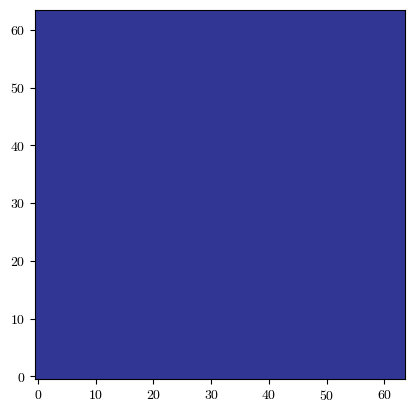

In [3]:
# Define galaxy profile, psf, and image params
gal = galsim.Gaussian(half_light_radius=1.0)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

npix = 64 # pixels per side
pix_scale = 0.2 # arcseconds

# Define shear components and convergence. We use exagerated values for clearly
# visible effects.
gamma1 = 0.2
gamma2 = -0.12
kappa = 0.08

# Instantiate LensTransform
lens_transform = batsim.LensTransform(
    gamma1=gamma1,
    gamma2=gamma2,
    kappa=kappa
)

# Instantiate the FlexionTransform with zeroed flexion terms
flexion_transform = batsim.FlexionTransform(
    gamma1=gamma1,
    gamma2=gamma2,
    kappa=kappa,
    F1=0,
    F2=0,
    G1=0,
    G2=0
)

# Simulate a galaxy with both transforms
lens_gal = batsim.simulate_galaxy(
    gal_obj=gal,
    psf_obj=psf,
    ngrid=npix,
    scale=pix_scale,
    transform_obj=lens_transform
)

flex_gal = batsim.simulate_galaxy(
    gal_obj=gal,
    psf_obj=psf,
    ngrid=npix,
    scale=pix_scale,
    transform_obj=flexion_transform
)

# Compare the two with batsim pltutil
resid = lens_gal - flex_gal
fig = batsim.pltutil.make_plot_image(resid)
print("Total residual:", resid.sum())

Evidently, with the flexion terms set to zero, the transform simplifies to the usual affine, lensing transform. So let's see what happens when we give them values.

$F_1$ and $F_2$ are associated with gradients in convergence, and as such, produce skewed, comet-like distortions, with $F_1$ controling horizontal distortions, and $F_2$ controling vertical ones.

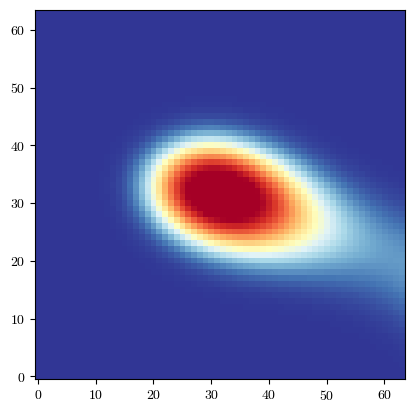

In [4]:
# Set F1 and F2 to something non-zero
flexion_transform = batsim.FlexionTransform(
    gamma1=gamma1,
    gamma2=gamma2,
    kappa=kappa,
    F1=0.06,
    F2=-0.04,
    G1=0,
    G2=0
)

# Re-render with new transform
flex_gal = batsim.simulate_galaxy(
    gal_obj=gal,
    psf_obj=psf,
    ngrid=npix,
    scale=pix_scale,
    transform_obj=flexion_transform
)

# Compare the two with batsim pltutil
fig = batsim.pltutil.make_plot_image(flex_gal)

As we can see, the galaxy clearly starts to skew towards the right of the image. $G_1$ and $G_2$ produce arc-like distortions. Together they represent a spin-3 field, so it not easy to intiutively think about the direction or type of distortion each controls, but to oversimplify, $G_1$ defines a reference pattern, and $G_2$ controls the rotation of that pattern.

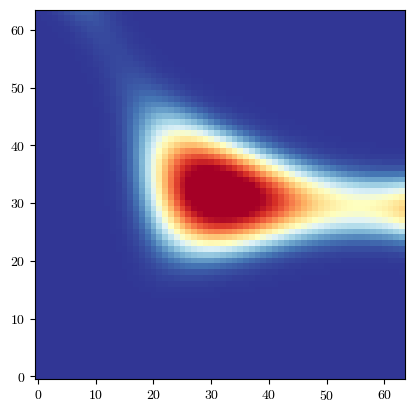

In [5]:
# Set G1 and G2 to something non-zero
flexion_transform = batsim.FlexionTransform(
    gamma1=gamma1,
    gamma2=gamma2,
    kappa=kappa,
    F1=0,
    F2=0,
    G1=0.3,
    G2=-0.02
)

# Re-render with new transform
flex_gal = batsim.simulate_galaxy(
    gal_obj=gal,
    psf_obj=psf,
    ngrid=npix,
    scale=pix_scale,
    transform_obj=flexion_transform
)

# Compare the two with batsim pltutil
fig = batsim.pltutil.make_plot_image(flex_gal)

We can start to see an arc forming. To help make it clearer what each parameter does, let's plot an 8-panel figure.

In [7]:
# Flexion amplitudes
F_amp = 0.3
G_amp = 0.3

# Each dictionary supplies one non-zero flexion component
flexion_modes = [
    (r"$+F_1$", dict(F1=+F_amp, F2=0.0, G1=0.0, G2=0.0)),
    (r"$-F_1$", dict(F1=-F_amp, F2=0.0, G1=0.0, G2=0.0)),
    (r"$+F_2$", dict(F1=0.0, F2=+F_amp, G1=0.0, G2=0.0)),
    (r"$-F_2$", dict(F1=0.0, F2=-F_amp, G1=0.0, G2=0.0)),
    (r"$+G_1$", dict(F1=0.0, F2=0.0, G1=+G_amp, G2=0.0)),
    (r"$-G_1$", dict(F1=0.0, F2=0.0, G1=-G_amp, G2=0.0)),
    (r"$+G_2$", dict(F1=0.0, F2=0.0, G1=0.0, G2=+G_amp)),
    (r"$-G_2$", dict(F1=0.0, F2=0.0, G1=0.0, G2=-G_amp)),
]

flexion_images = []

for title, components in flexion_modes:
    flexion_transform = batsim.FlexionTransform(
        gamma1=0.0,
        gamma2=0.0,
        kappa=0.0,
        **components, # parse flexion parameters
    )

    flex_gal = batsim.simulate_galaxy(
        gal_obj=gal,
        psf_obj=psf,
        ngrid=npix,
        scale=pix_scale,
        transform_obj=flexion_transform,
    )

    # Support either GalSim Image objects or array-like outputs.
    image = (
        flex_gal.array
        if hasattr(flex_gal, "array")
        else flex_gal
    )

    # Convert CuPy arrays to NumPy if necessary.
    if hasattr(image, "get"):
        image = image.get()

    flexion_images.append(np.asarray(image))

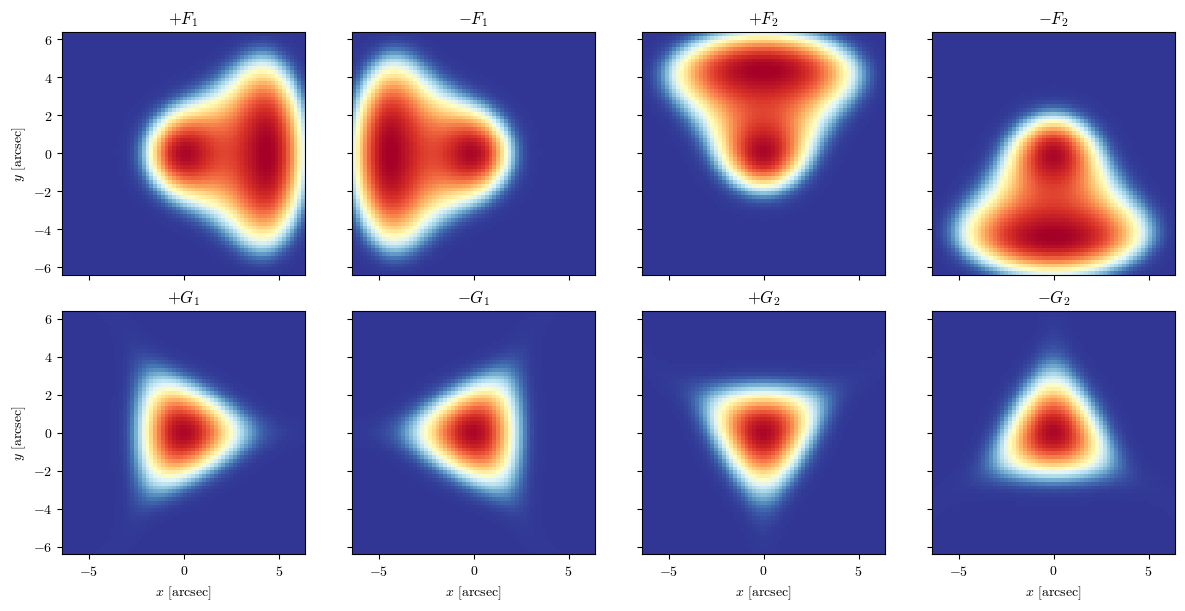

In [8]:
# Use one normalization across all panels so brightness differences remain
# meaningful.
vmax = max(image.max() for image in flexion_images)

norm = AsinhNorm(
    linear_width=0.01 * vmax,
    vmin=0.0,
    vmax=vmax,
)

# Display coordinates in arcseconds relative to the image centre.
half_width = 0.5 * npix * pix_scale
extent = [
    -half_width,
    +half_width,
    -half_width,
    +half_width,
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, (title, _), image in zip(
    axes.flat,
    flexion_modes,
    flexion_images,
):
    artist = ax.imshow(
        image,
        origin="lower",
        extent=extent,
        cmap="RdYlBu_r",
        norm=norm,
        interpolation="nearest",
    )

    ax.set_title(title)
    ax.set_aspect("equal")

# Only label the outer axes.
for ax in axes[-1, :]:
    ax.set_xlabel(r"$x$ [arcsec]")

for ax in axes[:, 0]:
    ax.set_ylabel(r"$y$ [arcsec]")

plt.show()

As with any non-affine transform, it is important you define the center of the shear field appropraitely relative to the center of the galaxy. As seen previously with ``IATransform``, this is done using the ``center`` argument.